In [5]:
import csv
import json
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────
BFCL_DIR = Path("/tmp/instance_storage/bfcl_eval_results")
BASELINE_PREFIX = "instance_storage__qwen3-30B-A3B"  # checkpoint_name for the base model

# Which scores to plot (column names from data_overall.csv).
# Set to None to plot all numeric/percentage columns.
SCORES_TO_PLOT = [
    # "Overall Acc",
    # "Non-Live AST Acc",
    # "Live Acc",
    # "Multi Turn Acc",
    "Memory Acc",
    # "Web Search Acc",
    # "Relevance Detection",
    # "Irrelevance Detection",
]

In [6]:
# ── 1. Load all checkpoint results ───────────────────────────────────


def parse_pct(val: str) -> float | None:
    """Parse '46.74%' -> 46.74, 'N/A' -> None."""
    if not val or val == "N/A":
        return None
    val = val.strip().rstrip("%")
    try:
        return float(val)
    except ValueError:
        return None


records = []  # list of dicts with checkpoint_name, model, iter_num, scores dict

for ckpt_dir in sorted(BFCL_DIR.iterdir()):
    overall_csv = ckpt_dir / "score" / "data_overall.csv"
    metadata_file = ckpt_dir / "metadata.json"
    if not overall_csv.exists():
        continue

    # Read scores
    with open(overall_csv) as f:
        reader = csv.DictReader(f)
        row = next(reader, None)
    if row is None:
        continue

    # Read metadata for checkpoint_name
    if metadata_file.exists():
        with open(metadata_file) as f:
            meta = json.load(f)
        ckpt_name = meta["checkpoint_name"]
        ts = meta["timestamp"]
    else:
        ckpt_name = ckpt_dir.name
        ts = ""

    # Parse model / iter from checkpoint_name
    m = re.match(r"^(.+)__iter_(\d+)$", ckpt_name)
    if m:
        model = m.group(1)
        iter_num = int(m.group(2))
    else:
        model = ckpt_name
        iter_num = None

    # Parse all percentage columns
    scores = {}
    for col, val in row.items():
        parsed = parse_pct(val)
        if parsed is not None:
            scores[col] = parsed

    records.append(
        {
            "checkpoint_name": ckpt_name,
            "model": model,
            "iter_num": iter_num,
            "timestamp": ts,
            "scores": scores,
        }
    )

print(f"Loaded {len(records)} checkpoint results")
for r in records:
    overall = r["scores"].get("Overall Acc", "N/A")
    print(f"  {r['checkpoint_name']:55s}  iter={r['iter_num']!s:>6s}  Overall Acc={overall}")

Loaded 11 checkpoint results
  batch_0_200_step_no_filter_hf__iter_0000019              iter=    19  Overall Acc=46.74
  batch_0_200_step_no_filter_hf__iter_0000039              iter=    39  Overall Acc=48.27
  batch_0_200_step_no_filter_hf__iter_0000059              iter=    59  Overall Acc=47.49
  batch_0_200_step_no_filter_hf__iter_0000079              iter=    79  Overall Acc=46.68
  batch_0_200_step_no_filter_hf__iter_0000099              iter=    99  Overall Acc=45.3
  batch_0_200_step_no_filter_hf__iter_0000119              iter=   119  Overall Acc=44.37
  batch_0_200_step_no_filter_hf__iter_0000139              iter=   139  Overall Acc=40.37
  batch_0_200_step_no_filter_hf__iter_0000159              iter=   159  Overall Acc=40.45
  batch_0_200_step_no_filter_hf__iter_0000179              iter=   179  Overall Acc=39.26
  batch_0_200_step_no_filter_hf__iter_0000199              iter=   199  Overall Acc=40.47
  instance_storage__qwen3-30B-A3B                          iter=  None  

In [7]:
# ── 2. Deduplicate & build per-model curves ─────────────────────────

# Deduplicate: for the same (model, iter_num), keep the newest timestamp
best = {}  # (model, iter_num) -> record
for r in records:
    key = (r["model"], r["iter_num"])
    if key not in best or r["timestamp"] > best[key]["timestamp"]:
        best[key] = r

print(f"{len(records)} records -> {len(best)} after dedup")

# Baseline (iter=None) becomes step 0 for every trained model
baseline_key = (BASELINE_PREFIX, None)
has_baseline = baseline_key in best
if has_baseline:
    baseline_scores = best[baseline_key]["scores"]
    print(f"Baseline: {BASELINE_PREFIX} (Overall Acc={baseline_scores.get('Overall Acc', 'N/A')})")
else:
    baseline_scores = {}
    print(f"Warning: baseline '{BASELINE_PREFIX}' not found, curves will not include step 0")

# Group trained checkpoints by model
model_points = defaultdict(list)  # model -> sorted list of (step, scores)
for (model, iter_num), r in best.items():
    if iter_num is None:
        continue
    model_points[model].append((iter_num + 1, r["scores"]))

for model in model_points:
    model_points[model].sort()

# Determine which score columns to plot
all_score_cols = set()
for r in records:
    all_score_cols.update(r["scores"].keys())
# Filter out non-interesting columns
SKIP_COLS = {
    "Rank",
    "Total Cost ($)",
    "Latency Mean (s)",
    "Latency Standard Deviation (s)",
    "Latency 95th Percentile (s)",
}
all_score_cols -= SKIP_COLS

if SCORES_TO_PLOT is not None:
    score_cols = [c for c in SCORES_TO_PLOT if c in all_score_cols]
else:
    score_cols = sorted(all_score_cols)

print(f"Score columns to plot: {score_cols}")

# Build curves: model -> {"steps": [...], "<score_col>": [...]}
curves = {}
for model, pts in model_points.items():
    if has_baseline:
        steps = [0] + [s for s, _ in pts]
    else:
        steps = [s for s, _ in pts]
    curves[model] = {"steps": steps}
    for col in score_cols:
        if has_baseline:
            curves[model][col] = [baseline_scores.get(col)] + [sc.get(col) for _, sc in pts]
        else:
            curves[model][col] = [sc.get(col) for _, sc in pts]

for model, c in sorted(curves.items()):
    print(f"  {model}: steps={c['steps']}")

11 records -> 11 after dedup
Baseline: instance_storage__qwen3-30B-A3B (Overall Acc=47.73)
Score columns to plot: ['Memory Acc']
  batch_0_200_step_no_filter_hf: steps=[0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]


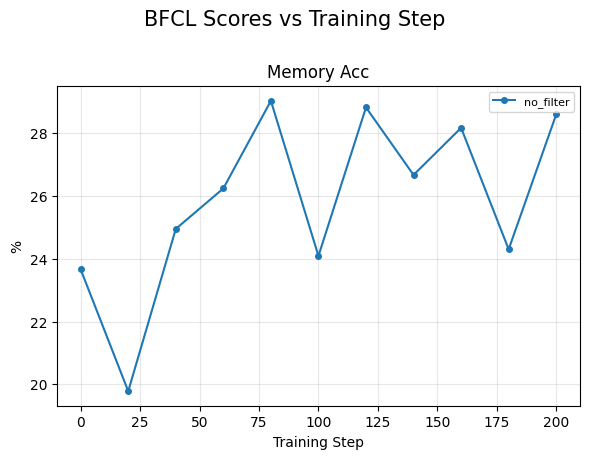

Saved to /tmp/instance_storage/bfcl_eval_results/bfcl_scores.png


In [8]:
# ── 3. Plot ──────────────────────────────────────────────────────────


def short_name(model: str) -> str:
    return model.replace("_hf", "").replace("batch_0_200_step_", "")


n_plots = len(score_cols)
n_cols = min(n_plots, 3)
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows), squeeze=False)
fig.suptitle("BFCL Scores vs Training Step", fontsize=15, y=1.01)

for idx, col in enumerate(score_cols):
    ax = axes[idx // n_cols][idx % n_cols]
    for model, c in sorted(curves.items()):
        vals = c[col]
        # Filter out None values (N/A scores)
        steps_filtered = [s for s, v in zip(c["steps"], vals, strict=False) if v is not None]
        vals_filtered = [v for v in vals if v is not None]
        if not vals_filtered:
            continue
        ax.plot(
            steps_filtered,
            vals_filtered,
            marker="o",
            markersize=4,
            linewidth=1.5,
            label=short_name(model),
        )
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Training Step")
    ax.set_ylabel("%")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(n_plots, n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].set_visible(False)

fig.tight_layout()
out_path = BFCL_DIR / "bfcl_scores.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out_path}")

In [9]:
# ── 4. Detailed table ────────────────────────────────────────────────

try:
    import pandas as pd

    rows = []
    for model, c in sorted(curves.items()):
        for i, step in enumerate(c["steps"]):
            row = {"model": short_name(model), "step": step}
            for col in score_cols:
                val = c[col][i]
                row[col] = f"{val:.2f}%" if val is not None else "N/A"
            rows.append(row)

    df = pd.DataFrame(rows)
    display(df)
except ImportError:
    print("pandas not installed, skipping table")

,model,step,Memory Acc
0,no_filter,0,23.66%
1,no_filter,20,19.78%
2,no_filter,40,24.95%
3,no_filter,60,26.24%
4,no_filter,80,29.03%
5,no_filter,100,24.09%
6,no_filter,120,28.82%
7,no_filter,140,26.67%
8,no_filter,160,28.17%
9,no_filter,180,24.30%
